<div style="display:none">
$$
\def\rvar#1{\mathrm{#1}}
\def\rvec#1{\mathbf{#1}}
\def\vec#1{\boldsymbol{#1}}
\def\tens#1{\boldsymbol{\mathsf{#1}}}
\def\tensel#1{\mathsf{#1}}
\def\st#1{\mathcal{#1}}
\def\diag#1{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/01_Introduction
    !pip install -q torch-geometric wandb

# some initialization stuff and general imports (see init.py for details)
%run ../init.py
%matplotlib inline

<IPython.core.display.Latex object>

# Useful functions

- Some functions were found to be useful when working with probability distributions, especially in Deep Learning (DL)

In [2]:
def sigmoid(x):
    return 1/(1+torch.exp(-1*x))

def logit(x):
    if x>0 and x<1: 
        return torch.log(x/(1 - x))

def softplus(x):
    return torch.log(1 + torch.exp(x))

def softmax(y):
    return torch.exp(y) / torch.sum(torch.exp(y))

dsigmoid = lambda x : sigmoid(x)*(1-sigmoid(x))

## Sigmoid (logistic) function
 
$$\sigma(x) = \frac{1}{1+\exp(-x)}$$

- Sigmoid is often used when the real values of the last hidden layer must be mapped to the range $(0,1)$, thus producing the $\phi$ parameter of a Bernoulli distribution
- Model marginal distributions $p(y_1), \dots, p(y_n)$
    - Makes sense for multi-label classification: big - yes/no and heavy - yes/no, etc.
- Is the inverse of the **logit** function - logarithm of odds $f(x)=\log\frac{x}{1-x}$
   - Given a probability $p$, $\sigma(\mathit{logit}(p))=p$   
- Derivative of a sigmoid is quite useful $\frac{d}{dx}\sigma(x) = \sigma(x)(1-\sigma(x))$

## Tanh activation function

- Sigmoid function might reduce the optimizer performance, since their derivative approaches to its optimum quite slowly
- Hyperbolic tangent activation function has quite similar properties as sigmoid
- Gradient is stronger than of sigmoid - possibly faster training

In [3]:
sigmoid = lambda x: 1/(1+torch.exp(-1*x))
tanh = lambda x: 2/(1 + torch.exp(-2*x)) - 1

sp = torch.linspace(-5, 5, 101)

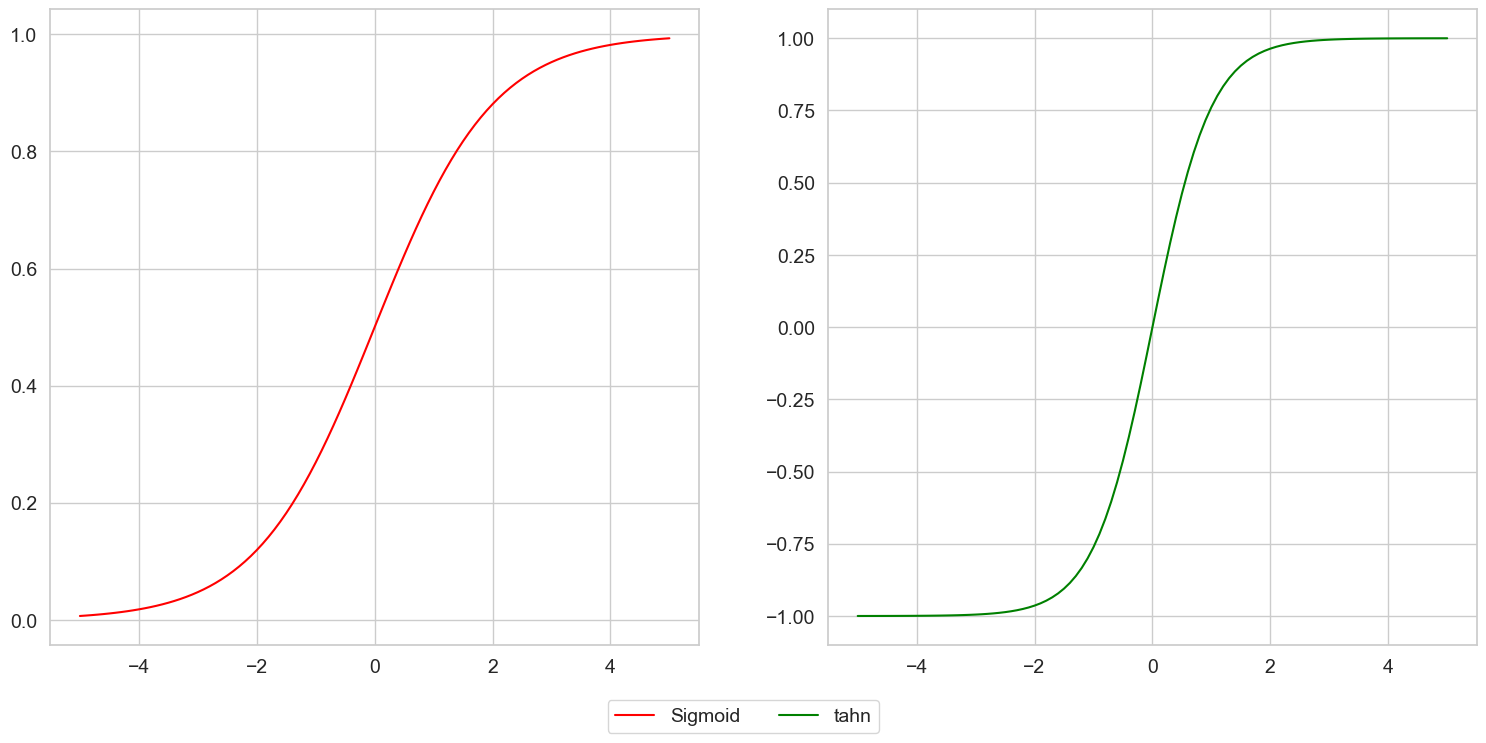

In [4]:
fig, ax = plt.subplots(1,2,figsize=(16,8))
ax[0].plot(sp, list(map(sigmoid, sp)), color="red", label="Sigmoid")
ax[1].plot(sp, list(map(tanh, sp)), color="green", label="tahn")
fig.legend(loc="lower center", ncol=3)
fig.tight_layout(pad=3)

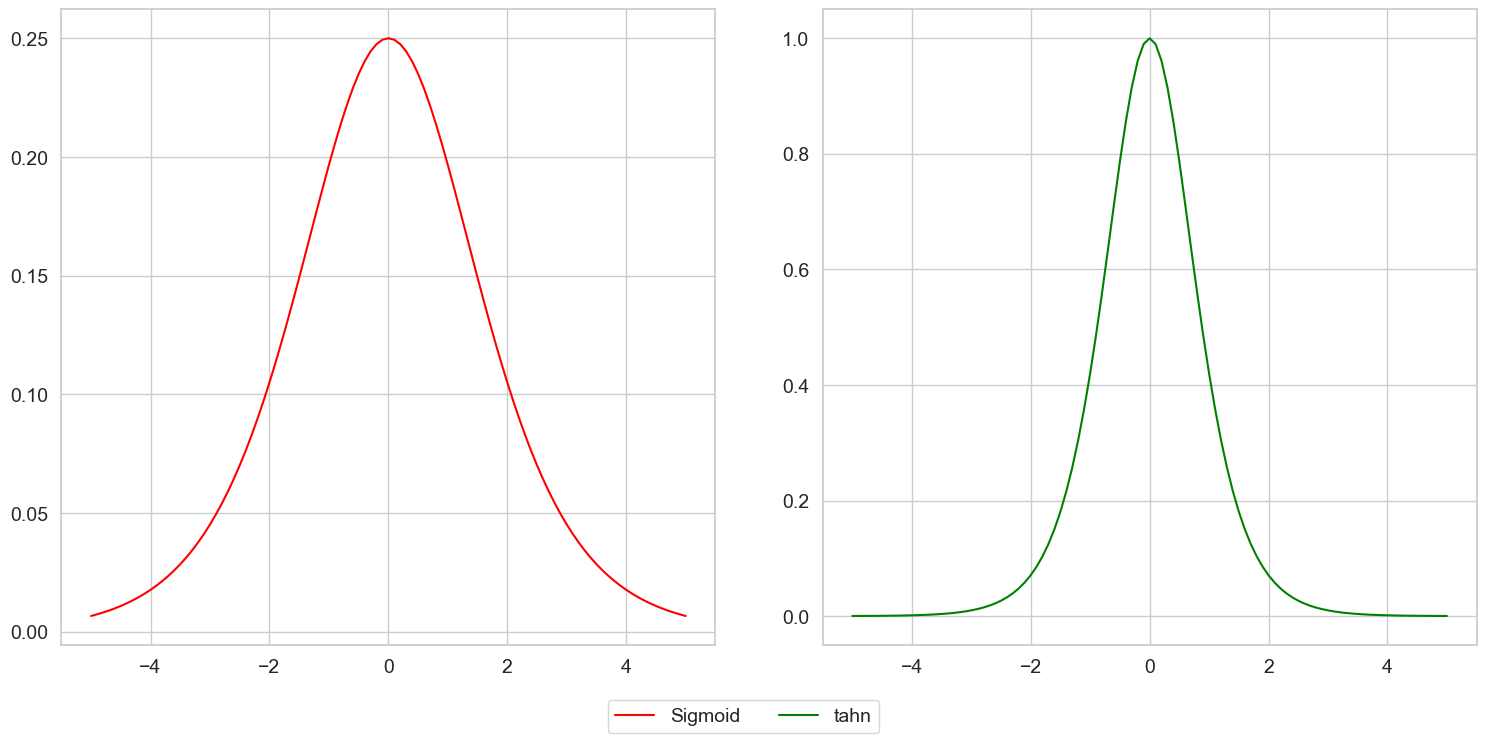

In [5]:
dsigmoid = lambda x : sigmoid(x)*(1-sigmoid(x))
dtanh = lambda x : 1 - pow(tanh(x),2)

fig, ax = plt.subplots(1,2,figsize=(16,8))
ax[0].plot(sp, list(map(dsigmoid, sp)), color="red", label="Sigmoid")
ax[1].plot(sp, list(map(dtanh, sp)), color="green", label="tahn")
fig.legend(loc="lower center", ncol=2)
fig.tight_layout(pad=3)

## Softplus function

$$\zeta(x) = \log(1+\exp(x))$$

- Can be useful for producing the $\sigma$ parameter of the normal distribution
- Used to manipulate expressions with sigmoids, since
   - $\frac{d}{dx}\zeta(x) = \sigma(x)$, 
   - $\zeta(x) = \int_{-\infty}^x \sigma(y)\, \mathit{dy}$, and 
   - $\log\sigma(x)=-\zeta(-x)$

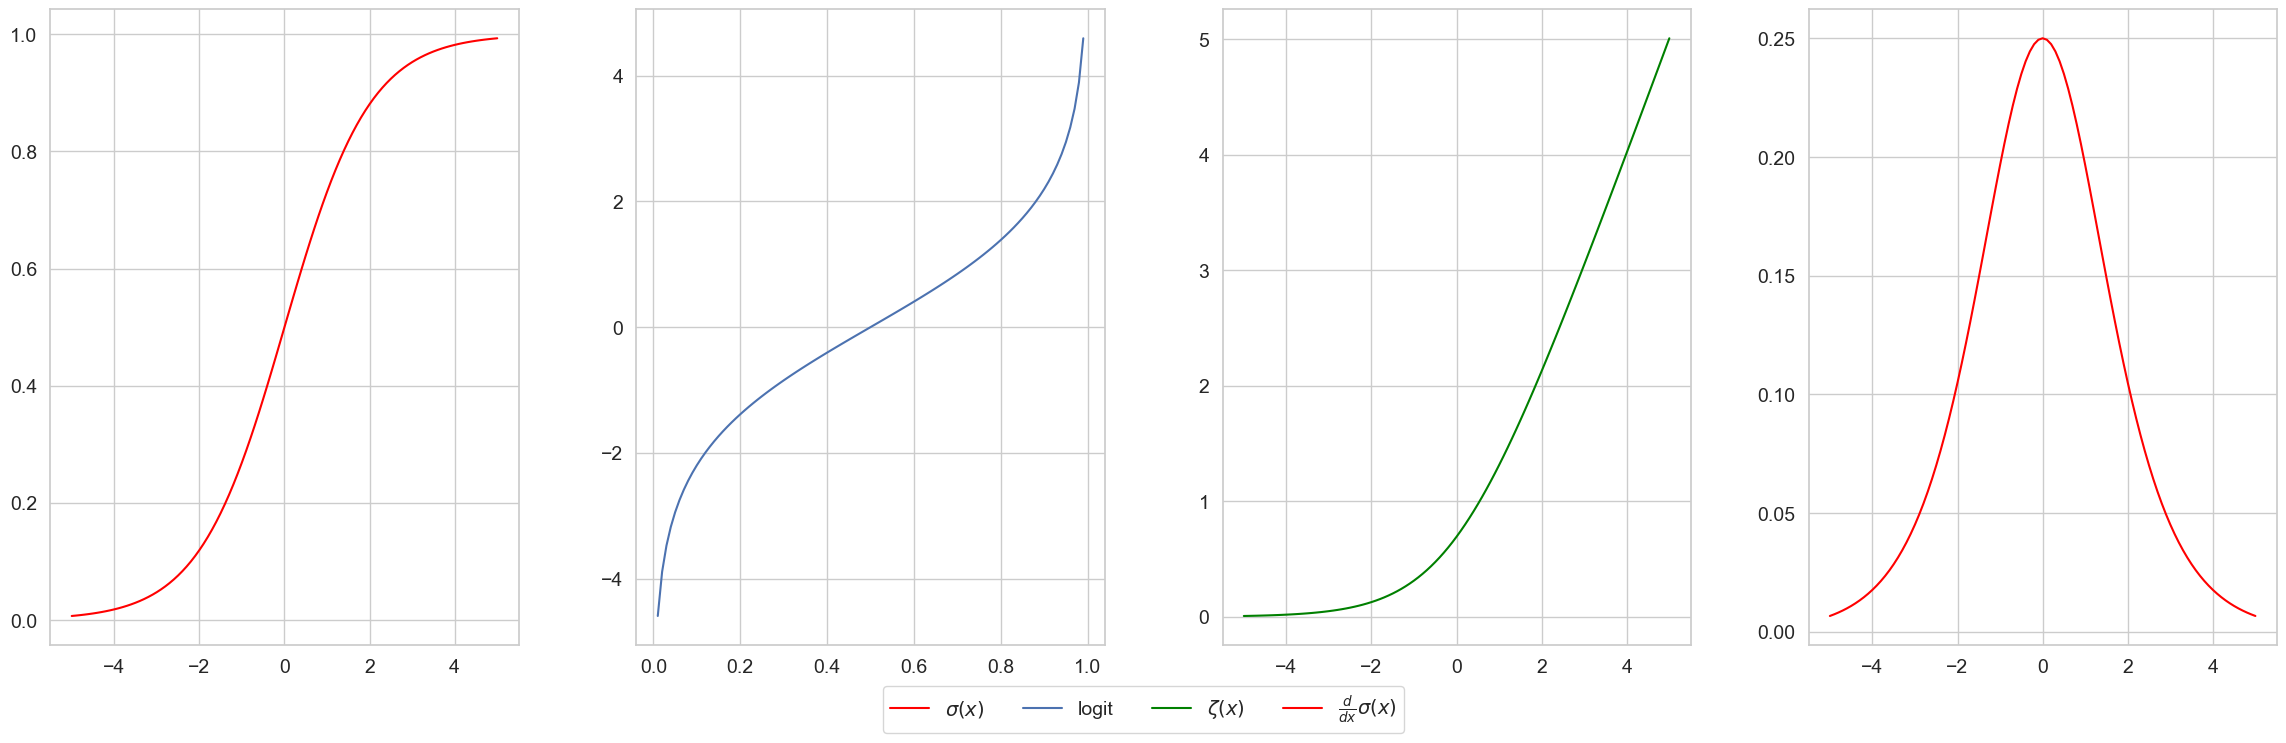

In [6]:
sp = torch.linspace(-5, 5, 101)
lp = torch.linspace(0, 1, 101)
fig, ax = plt.subplots(1,4,figsize=(24,8))
ax[0].plot(sp, list(map(sigmoid, sp)), color="red", label=r'$\sigma(x)$')
ax[1].plot(lp, list(map(logit, lp)), label="logit")
ax[2].plot(sp, list(map(softplus, sp)), color="green", label=r'$\zeta(x)$')
ax[3].plot(sp, list(map(dsigmoid, sp)), color="red", label=r'$\frac{d}{dx}\sigma(x)$')
fig.legend(loc="lower center", ncol=4)
fig.tight_layout(pad=3)

## Softmax function

- Given a vector $\vec{y}$ of real numbers $y \in(-\infty, \infty)$, aka. logits, the softmax function can convert them into a probability distribution
$$S(y_i) = \frac{e^{y_i}}{\sum_j e^{y_j}}$$
- Output values of $S(\vec{y})$ are in $[0,1]$ and sum up to 1 - probability distribution $p(y_1, \dots, y_n)$, 
- Makes sense for exclusive labels $y_1, \dots, y_n$: image class - cat, dog, human, etc.

In [7]:
y = torch.tensor([-1, 1, -2, 5])
print("Given logits: {} \nSigmoid output: {}\nSoftmax output: {}\nSum: {}"
      .format(y, sigmoid(y), softmax(y), torch.sum(softmax(y))))

Given logits: tensor([-1,  1, -2,  5]) 
Sigmoid output: tensor([0.2689, 0.7311, 0.1192, 0.9933])
Softmax output: tensor([2.4261e-03, 1.7927e-02, 8.9251e-04, 9.7875e-01])
Sum: 1.0


## ReLU function

- *Rectified Linear Unit (ReLU)* is a "hard" version of the softplus and is one of the most used activation function in the DL architectures


$$\mathit{relu}(x) = \max(0,x)$$


- Derivative $\frac{\partial}{\partial x}\mathit{relu}$ is undefined in $x=0$ 
    - different values of the left and right derivatives
    
    
$$\partial_+\mathit{relu}(0) \neq \partial_-\mathit{relu}(0) \quad\mathsf{ since }\qquad \lim_{x\to 0^+}\frac{\mathit{relu}(x)-0}{x-0}>\lim_{x\to 0^-}\frac{\mathit{relu}(x)-0}{x-0}=0$$


- Any value between $0$ and $1$ can be selected for $x=0$
    - Quite often, e.g. in TensorFlow and Pytorch, a value $0$ is selected to end-up with a sparser tensors (multi-dimensional arrays) of weights


## Versions of ReLU

- *ReLU* problem: there is no possibility to differentiate between small and large negative inputs by observing the value of the function
- This might cause issues when ReLU is used in DL architectures
- "Softer" versions ReLU versions help to solve this problem
- *Leaky ReLU*, where a "leak" is used to increase the range from $[0,\infty)$ to $(-\infty,\infty)$
    - If $\alpha$ is not fixed, then this activation function is called *Parametric Rectified Linear Unit* and $\alpha$ is learned during the training


$$\mathit{lrelu}(x) = \max(\alpha x,x), \text { where } \alpha < 1$$


- *Exponential Linear Unit* (ELU) 
$$\mathit{elu}(x) = \begin{cases} 
      \alpha(e^x-1) & x \leq 0 \\
      x & x > 0
   \end{cases}$$
- ELU approaches smoothly to 0 for negative values of $x$

In [8]:
def relu(x):
    return max(0, x)

def leaky_relu(x):
    return max(0.2*x, x)

def elu(x, alpha = 0.5):
    if x > 0: return x
    else: return alpha*(np.exp(x)-1)

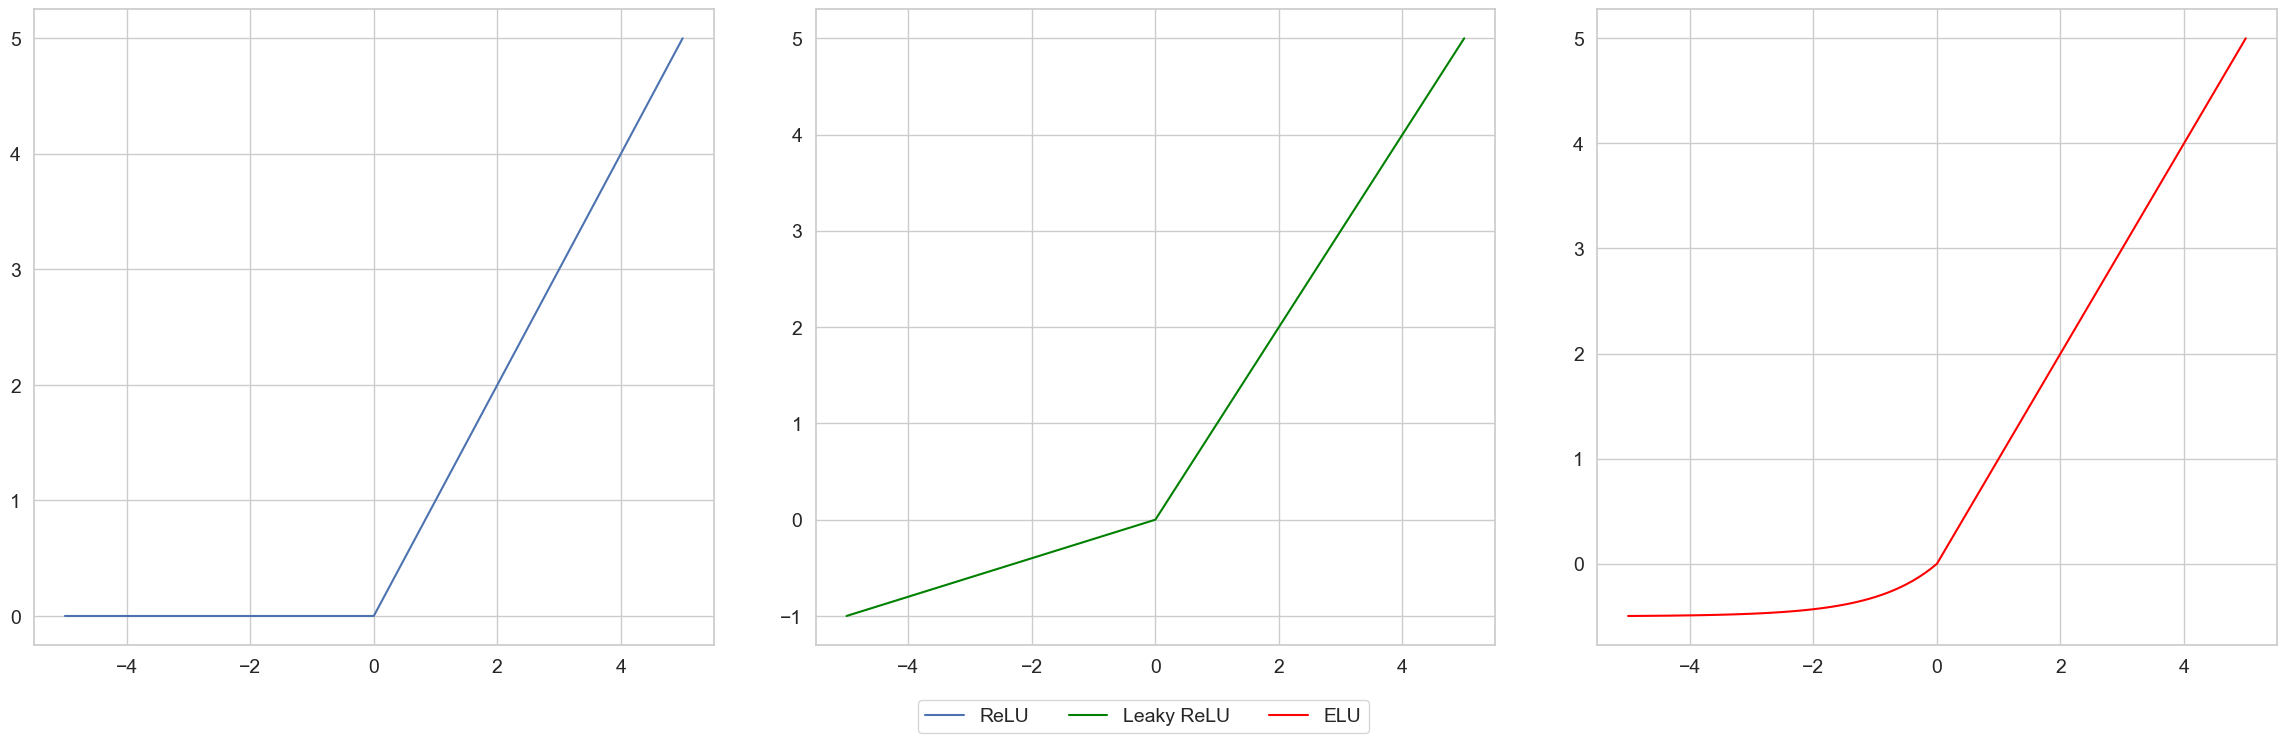

In [9]:
fig, ax = plt.subplots(1,3,figsize=(24,8))
ax[0].plot(sp, list(map(relu, sp)), label="ReLU")
ax[1].plot(sp, list(map(leaky_relu, sp)), color="green", label="Leaky ReLU")
ax[2].plot(sp, list(map(elu, sp)), color="red", label="ELU")
fig.legend(loc="lower center", ncol=3)
fig.tight_layout(pad=3)

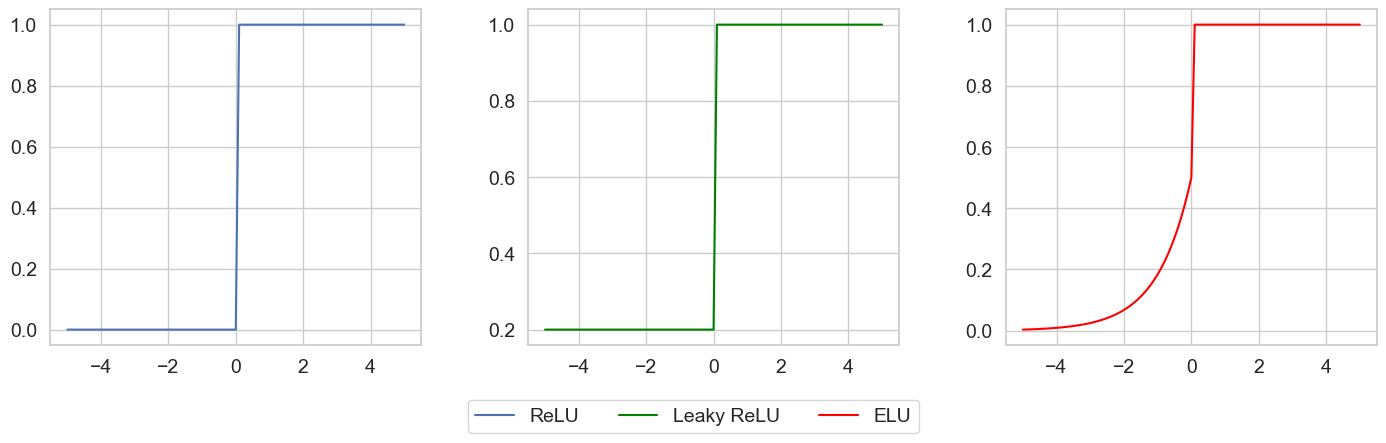

In [10]:
drelu = lambda x : 1 if (x>0) else (np.nan if (x==0) else 0)
dlrelu = lambda x : 1 if (x>0) else (np.nan if (x==0) else 0.2)
delu = lambda x : 1 if (x>0) else (np.nan if (x==0) else 0.5*math.exp(x))

fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].plot(sp, list(map(drelu, sp)), label="ReLU")
ax[1].plot(sp, list(map(dlrelu, sp)), color="green", label="Leaky ReLU")
ax[2].plot(sp, list(map(delu, sp)), color="red", label="ELU")
fig.legend(loc="lower center", ncol=3)
fig.tight_layout(pad=3)